In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

print("Train Shape :", train_df.shape)
print("Test Shape :", test_df.shape)

train_df.head()

Train Shape : (7613, 5)
Test Shape : (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
print(train_df.isnull().sum())

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


In [4]:
train_df = train_df[["text", "target"]]
test_df = test_df[["text"]]

train_df.head()

,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
train_texts, valid_texts, train_labels, valid_labels = train_test_split(
    train_df["text"],
    train_df["target"],
    test_size=0.2,
    random_state=42,
    stratify=train_df["target"]
)

In [6]:
train_dataset = Dataset.from_dict({
    "text": train_texts.tolist(),
    "labels": train_labels.tolist()
})

valid_dataset = Dataset.from_dict({
    "text": valid_texts.tolist(),
    "labels": valid_labels.tolist()
})

test_dataset = Dataset.from_dict({
    "text": test_df["text"].tolist()
})

In [7]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [8]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
valid_dataset = valid_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1523 [00:00<?, ? examples/s]

Map:   0%|          | 0/3263 [00:00<?, ? examples/s]

In [9]:
train_dataset = train_dataset.remove_columns(["text"])
valid_dataset = valid_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

In [10]:
train_dataset.set_format("torch")
valid_dataset.set_format("torch")
test_dataset.set_format("torch")

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [14]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="./logs",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [15]:
import transformers
print(transformers.__version__)

5.14.1


In [16]:
tokenizer=tokenizer

In [17]:
print(training_args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval

In [18]:
print(train_dataset)
print(valid_dataset)

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6090
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1523
})


In [19]:
print(model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [20]:
print(type(train_dataset))

<class 'datasets.arrow_dataset.Dataset'>


In [21]:
print(compute_metrics)

<function compute_metrics at 0x0000019A3DD1FA00>


In [22]:
import transformers
print(transformers.__version__)

5.14.1


In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    
    compute_metrics=compute_metrics
)

In [24]:
trainer.train()

c:\Users\Lenovo\Documents\ML Project_Payoda\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.367302,0.852922,0.883929,0.756881,0.815486
2,0.417623,0.423472,0.827315,0.780488,0.831804,0.805329
3,0.292301,0.421855,0.843729,0.830159,0.799694,0.814642


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Lenovo\Documents\ML Project_Payoda\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Lenovo\Documents\ML Project_Payoda\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1143, training_loss=0.3440264570848627, metrics={'train_runtime': 6292.0086, 'train_samples_per_second': 2.904, 'train_steps_per_second': 0.182, 'total_flos': 605044843361280.0, 'train_loss': 0.3440264570848627, 'epoch': 3.0})

In [25]:
results = trainer.evaluate()

print(results)

c:\Users\Lenovo\Documents\ML Project_Payoda\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.292301,0.367302,3,0.852922,0.883929,0.756881,0.815486


{'eval_loss': 0.3673018217086792, 'eval_accuracy': 0.8529218647406435, 'eval_precision': 0.8839285714285714, 'eval_recall': 0.7568807339449541, 'eval_f1': 0.8154859967051071}


In [26]:
print("Accuracy :", results["eval_accuracy"])
print("Precision:", results["eval_precision"])
print("Recall   :", results["eval_recall"])
print("F1 Score :", results["eval_f1"])

Accuracy : 0.8529218647406435
Precision: 0.8839285714285714
Recall   : 0.7568807339449541
F1 Score : 0.8154859967051071


In [27]:
from sklearn.metrics import classification_report

predictions = trainer.predict(valid_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred))

c:\Users\Lenovo\Documents\ML Project_Payoda\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           0       0.83      0.93      0.88       869
           1       0.88      0.76      0.82       654

    accuracy                           0.85      1523
   macro avg       0.86      0.84      0.85      1523
weighted avg       0.86      0.85      0.85      1523



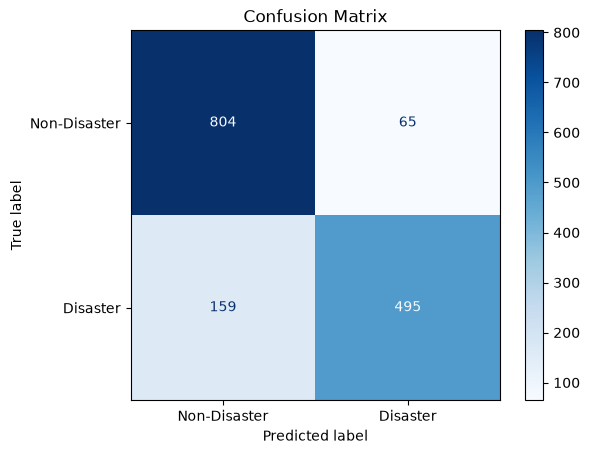

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Disaster", "Disaster"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [29]:
test_predictions = trainer.predict(test_dataset)

test_preds = test_predictions.predictions.argmax(axis=1)

c:\Users\Lenovo\Documents\ML Project_Payoda\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [30]:
submission = pd.read_csv("../data/sample_submission.csv")

submission["target"] = test_preds

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!


In [31]:
submission.to_csv("submission.csv", index=False)